In [1]:
#%load_ext autoreload
#%autoreload 2

import sys
import pathlib

# Ensure the notebook can import the local src package from the project root.
project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.io import fits
import sunpy.map

In [2]:
data_dir = pathlib.Path('../data/raw/sebastian_sun_spots')  


# Data Sebastián análisis

## preliminar

In [3]:
DS03_dir = data_dir.joinpath('DS03')
cube_continuum = DS03_dir / 'cube_continuum.fits'
cube_dopplergram = DS03_dir / 'cube_dopplergram_corrected.fits'
cube_magnetogram = DS03_dir / 'cube_magnetogram.fits'

In [4]:
#list of all the fits files in the data directory
fits_files = list(DS03_dir.glob('*.fits'))
fits_files

[PosixPath('../data/raw/sebastian_sun_spots/DS03/disambig_ref.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_magnetogram.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_xcoord.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_dopplergram_qsun.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_dopplergram.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/azimuth_ref.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_continuum.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_ycoord.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_continuum_qsun.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/units.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/Dopplergram_ref.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_dopplergram_corrected.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/cube_mu.fits'),
 PosixPath('../data/raw/sebastian_sun_spots/DS03/inclination_r

In [5]:
# Open the corrected Continuum cube — it has a minimal IDL header
cube_path = DS03_dir / 'cube_continuum.fits'
with fits.open(cube_path) as hdul:
    cube_header = hdul[0].header
    cube_shape  = hdul[0].data.shape  # (time, y, x)
    cube_data   = hdul[0].data
print('=== Continuum cube header (IDL format) ===')
print(repr(cube_header))

=== Continuum cube header (IDL format) ===
SIMPLE  =                    T / Written by IDL:  Thu Mar 11 09:16:25 2021      
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                  239 /                                                
NAXIS2  =                  240 /                                                
NAXIS3  =                 1084 /                                                
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2021-03-11'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    


In [6]:
# Open the corrected Dopplergram cube — it has a minimal IDL header
cube_path = DS03_dir / 'cube_dopplergram_corrected.fits'
with fits.open(cube_path) as hdul:
    cube_header = hdul[0].header
    cube_shape  = hdul[0].data.shape  # (time, y, x)
    cube_data   = hdul[0].data

print('=== cube_dopplergram_corrected.fits header ===')
print(repr(cube_header))
print(f'\nData shape (time, y, x): {cube_shape}')

# Full spatial/WCS metadata lives in Dopplergram_ref.fits
with fits.open(DS03_dir / 'Dopplergram_ref.fits') as hdul:
    ref_header = hdul[0].header

print('\n=== Dopplergram_ref.fits header (spatial metadata) ===')
print(repr(ref_header))


2026-06-10 22:53:59 - astropy - WARNING: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.


=== cube_dopplergram_corrected.fits header ===
SIMPLE  =                    T / Written by IDL:  Fri Mar 12 07:31:17 2021      
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                  239 /                                                
NAXIS2  =                  240 /                                                
NAXIS3  =                 1084 /                                                
EXTEND  =                    T / FITS data may contain extensions               
DATE    = '2021-03-12'         / Creation UTC (CCCC-MM-DD) date of FITS header  
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    

Data shape (time, y, x): (1084, 240, 239)

=== Dopplergram_ref.fits header (spatial metadata) ===
SIMPLE  =                    T / Written by 

In [10]:
cube_data.shape

(1084, 240, 239)

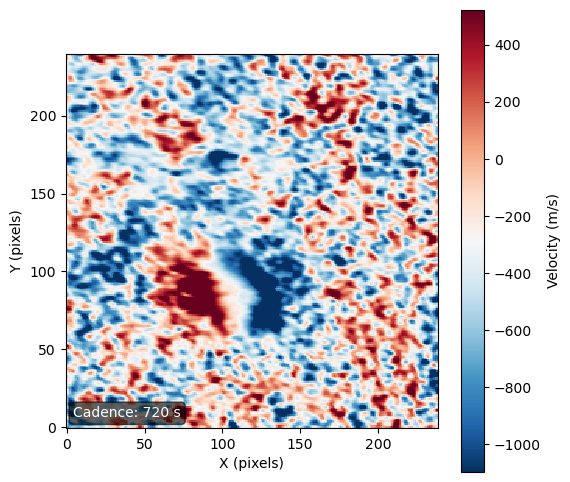

In [11]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

CADENCE_S = 720  # seconds per frame (HMI 720-s series)
STEP = 5         # subsample: every 5th frame keeps the animation manageable

# Mask fill values (~-1.18e+29) and any extreme outliers
cube_masked = np.where(np.abs(cube_data) > 1e4, np.nan, cube_data.astype(float))

frames_idx = np.arange(0, cube_masked.shape[0], STEP)
vmin, vmax = np.nanpercentile(cube_masked, [2, 98])

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cube_masked[0], origin='lower', cmap='RdBu_r',
               vmin=vmin, vmax=vmax, interpolation='nearest')
fig.colorbar(im, ax=ax, label='Velocity (m/s)')

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

# Fixed cadence label in bottom-left corner
ax.text(0.02, 0.02, f'Cadence: {CADENCE_S} s',
        transform=ax.transAxes, color='white', fontsize=10,
        va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))

title = ax.set_title('')

def _update(i):
    t = frames_idx[i]
    im.set_data(cube_masked[t])
    elapsed_h = t * CADENCE_S / 3600
    title.set_text(f'SDO/HMI Dopplergram  —  frame {t:04d}  |  t = {elapsed_h:.2f} h')
    return im, title

#anim = FuncAnimation(fig, _update, frames=len(frames_idx), interval=80, blit=True)
#plt.close(fig)

#HTML(anim.to_jshtml())

In [12]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
def create_dopplergram_animation():
    CADENCE_S = 720  # seconds per frame (HMI 720-s series)
    STEP = 5         # subsample: every 5th frame keeps the animation manageable

    # Mask fill values (~-1.18e+29) and any extreme outliers
    cube_masked = np.where(np.abs(cube_data) > 1e4, np.nan, cube_data.astype(float))

    frames_idx = np.arange(0, cube_masked.shape[0], STEP)
    vmin, vmax = np.nanpercentile(cube_masked, [2, 98])

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cube_masked[0], origin='lower', cmap='RdBu_r',
                vmin=vmin, vmax=vmax, interpolation='nearest')
    fig.colorbar(im, ax=ax, label='Velocity (m/s)')

    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

    # Fixed cadence label in bottom-left corner
    ax.text(0.02, 0.02, f'Cadence: {CADENCE_S} s',
            transform=ax.transAxes, color='white', fontsize=10,
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))

    title = ax.set_title('')

    def _update(i):
        t = frames_idx[i]
        im.set_data(cube_masked[t])
        elapsed_h = t * CADENCE_S / 3600
        title.set_text(f'SDO/HMI Dopplergram  —  frame {t:04d}  |  t = {elapsed_h:.2f} h')
        return im, title

    anim = FuncAnimation(fig, _update, frames=len(frames_idx), interval=80, blit=True)
    plt.close(fig)



    HTML(anim.to_jshtml())
#create_dopplergram_animation();

## consolidated

In [13]:
# compute cadence 

# read .sav file 

from scipy.io import readsav

sav_data = readsav(DS03_dir / 'cube_continuum_coords2times.sav')
sav_data.keys()


dict_keys(['hdrs', 'times', 'xd', 'yd'])

In [14]:
import datetime

result = sav_data['times'].flatten().astype(str)

times = [datetime.datetime.strptime(time, '%d-%b-%Y %H:%M:%S.%f') for time in result]
# compute cadence from times
time_diffs = np.diff(times)
time_diffs_seconds = np.array([td.total_seconds() for td in time_diffs])
time_diffs_seconds

array([720., 720., 720., ..., 720., 720., 720.], shape=(1083,))

In [50]:
FILL = 1e6          # fill-value sentinel threshold
CADENCE_S = 720     # seconds per frame

# ── load the three channels ──────────────────────────────────────────────────
def load_cube(path):
    with fits.open(path) as hdul:
        arr = hdul[0].data.astype(float)
    return np.where(np.abs(arr) > FILL, np.nan, arr)

cube_cont = load_cube(DS03_dir / 'cube_continuum.fits')
cube_mag  = load_cube(DS03_dir / 'cube_magnetogram.fits')
cube_dop  = load_cube(DS03_dir / 'cube_dopplergram_corrected.fits')
cube_dop_qsun = load_cube(DS03_dir / 'cube_dopplergram_qsun.fits')
cube_mag_qsun = load_cube(DS03_dir / 'cube_magnetogram_qsun.fits')

print('continuum  :', cube_cont.shape, f'  range [{np.nanmin(cube_cont):.0f}, {np.nanmax(cube_cont):.0f}]')
print('magnetogram:', cube_mag.shape,  f'  range [{np.nanmin(cube_mag):.0f}, {np.nanmax(cube_mag):.0f}] G')
print('dopplergram:', cube_dop.shape,  f'  range [{np.nanmin(cube_dop):.0f}, {np.nanmax(cube_dop):.0f}] m/s')
print('dopplergram_qsun:', cube_dop_qsun.shape,  f'  range [{np.nanmin(cube_dop_qsun):.0f}, {np.nanmax(cube_dop_qsun):.0f}] m/s')
print('magnetogram_qsun:', cube_mag_qsun.shape,  f'  range [{np.nanmin(cube_mag_qsun):.0f}, {np.nanmax(cube_mag_qsun):.0f}] G')

continuum  : (1084, 240, 239)   range [9427, 68959]
magnetogram: (1084, 240, 239)   range [-1446, 2005] G
dopplergram: (1084, 240, 239)   range [-3581, 3030] m/s
dopplergram_qsun: (1084, 60, 60)   range [-3535, 3831] m/s
magnetogram_qsun: (1084, 60, 60)   range [-644, 619] G


In [51]:
CONT_THRESH_UMB = 30_000   # penumbra: continuum > 30 000 DN
CONT_THRESH_PEM = 50_000   # umbra: continuum < 10 000 DN

# boolean mask (time, y, x) — penumbra pixels at each frame
umbra = (cube_cont < CONT_THRESH_UMB) & np.isfinite(cube_cont)
penumbra = (cube_cont < CONT_THRESH_PEM) & np.isfinite(cube_cont) & ~umbra
both = (cube_cont < CONT_THRESH_PEM) & np.isfinite(cube_cont)  
#quiet_sun = (cube_cont >= CONT_THRESH_UMB) & np.isfinite(cube_cont)

n_t = cube_cont.shape[0]
time_h = np.arange(n_t) * CADENCE_S / 3600   # hours




In [ ]:

#from scipy.ndimage import center_of_mass
## Assuming 'matrix' has the shape (1084, 240, 239)
## This loops through each frame and calculates its 2D center of intensity
#cms = np.array([center_of_mass(penumbra[i]) for i in range(penumbra.shape[0])])

#radius = 50

#filter_matrix = np.zeros_like(penumbra)

#for i in range(penumbra.shape[0]):
#     y, x = cms[i]
#     y, x = int(round(y)), int(round(x))
#     filter_matrix[i, max(0, y-radius):y+radius, max(0, x-radius):x+radius] = True

# crop_penumbra = filter_matrix & penumbra


In [52]:
from scipy import ndimage
import numpy as np


def keep_central_cluster(binary_img, mode='largest'):
    """
    binary_img: 2D numpy array of 0s and 1s
    mode: 'largest' keeps biggest cluster, 'central' keeps cluster nearest image center
    """
    labeled, n = ndimage.label(binary_img)
    if n == 0:
        return binary_img

    if mode == 'largest':
        sizes = ndimage.sum(binary_img, labeled, range(1, n + 1))
        keep = np.argmax(sizes) + 1
    else:  # 'central'
        cy, cx = np.array(binary_img.shape) / 2
        centroids = ndimage.center_of_mass(binary_img, labeled, range(1, n + 1))
        dists = [np.hypot(y - cy, x - cx) for y, x in centroids]
        keep = np.argmin(dists) + 1

    return (labeled == keep).astype(binary_img.dtype)

umbra_cropped = np.array([keep_central_cluster(umbra[i], mode='largest') for i in range(cube_cont.shape[0])], dtype=bool)
penumbra_cropped = np.array([keep_central_cluster(penumbra[i], mode='largest') for i in range(penumbra.shape[0])], dtype=bool)

In [53]:
penumbra = penumbra_cropped
umbra = umbra_cropped

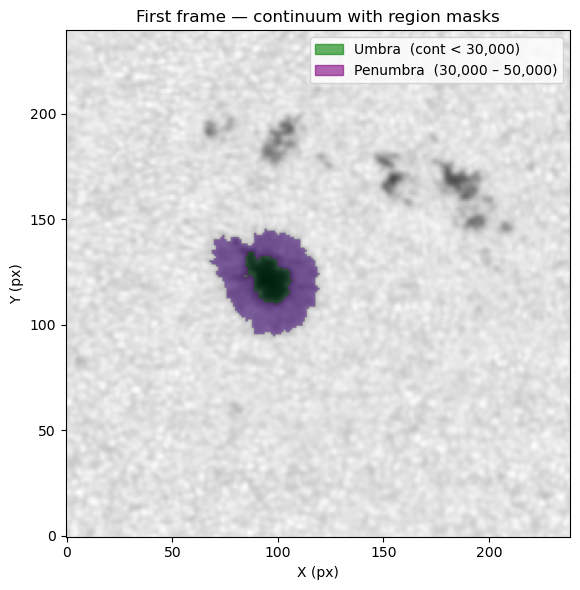

In [54]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 6))

image_idx = 500

ax.imshow(cube_cont[image_idx], cmap='gray', origin='lower')
ax.imshow(np.where(umbra[image_idx],    1.0, np.nan), cmap='Greens',  alpha=0.5, origin='lower', vmin=0, vmax=1)
ax.imshow(np.where(penumbra[image_idx], 1.0, np.nan), cmap='Purples', alpha=0.5, origin='lower', vmin=0, vmax=1)
ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
ax.set_title('First frame — continuum with region masks')
ax.legend(handles=[
    mpatches.Patch(color='green',  alpha=0.6, label=f'Umbra  (cont < {CONT_THRESH_UMB:,})'),
    mpatches.Patch(color='purple', alpha=0.6, label=f'Penumbra  ({CONT_THRESH_UMB:,} – {CONT_THRESH_PEM:,})'),
], loc='upper right')
plt.tight_layout()
plt.show()

### create beter regions for magnetogram

/tmp/ipykernel_29249/604934986.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 700x700 with 2 Axes> than <Figure size 600x600 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(im, ax=ax, label='B  (G)', fraction=0.046, pad=0.04)


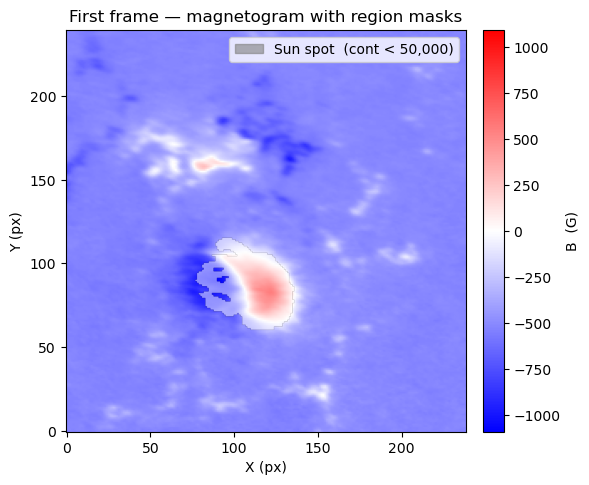

In [55]:
sun_spot = umbra + penumbra

fig, ax = plt.subplots(figsize=(6, 6))

image_idx = 1
fig.colorbar(im, ax=ax, label='B  (G)', fraction=0.046, pad=0.04)

ax.imshow(cube_mag[image_idx], cmap='bwr', origin='lower')
ax.imshow(np.where(sun_spot[image_idx],    1.0, np.nan), cmap='gray',  alpha=0.5, origin='lower', vmin=0, vmax=1)
ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
ax.set_title('First frame — magnetogram with region masks')
ax.legend(handles=[
    mpatches.Patch(color='gray',  alpha=0.6, label=f'Sun spot  (cont < {CONT_THRESH_PEM:,})')
], loc='upper right')
plt.tight_layout()
plt.show()

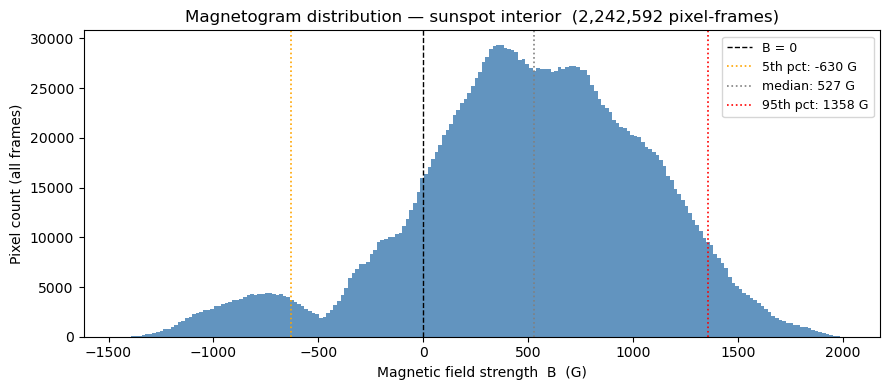

min=-1446  p1=-1035  p5=-630  p25=174  median=527  p75=898  p95=1358  p99=1630  max=2005 G


In [56]:
# create an histogram of all the cube out of all the values of the magnetogram inside the region sunspot
# ── Magnetogram histogram — all pixel values inside the sunspot (all frames) ──
mag_in_spot = cube_mag[both]
mag_in_spot = mag_in_spot[np.isfinite(mag_in_spot)]

p1, p5, p25, p50, p75, p95, p99 = np.nanpercentile(mag_in_spot, [1, 5, 25, 50, 75, 95, 99])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(mag_in_spot, bins=200, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('Magnetic field strength  B  (G)')
ax.set_ylabel('Pixel count (all frames)')
ax.set_title(f'Magnetogram distribution — sunspot interior  ({both.sum():,} pixel-frames)')
ax.axvline(0,   color='black',  lw=1.0, ls='--', label='B = 0')
for val, lbl, col in [(p5, '5th pct', 'orange'), (p50, 'median', 'gray'), (p95, '95th pct', 'red')]:
    ax.axvline(val, color=col, lw=1.2, ls=':', label=f'{lbl}: {val:.0f} G')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'min={mag_in_spot.min():.0f}  p1={p1:.0f}  p5={p5:.0f}  p25={p25:.0f}  '
      f'median={p50:.0f}  p75={p75:.0f}  p95={p95:.0f}  p99={p99:.0f}  max={mag_in_spot.max():.0f} G')

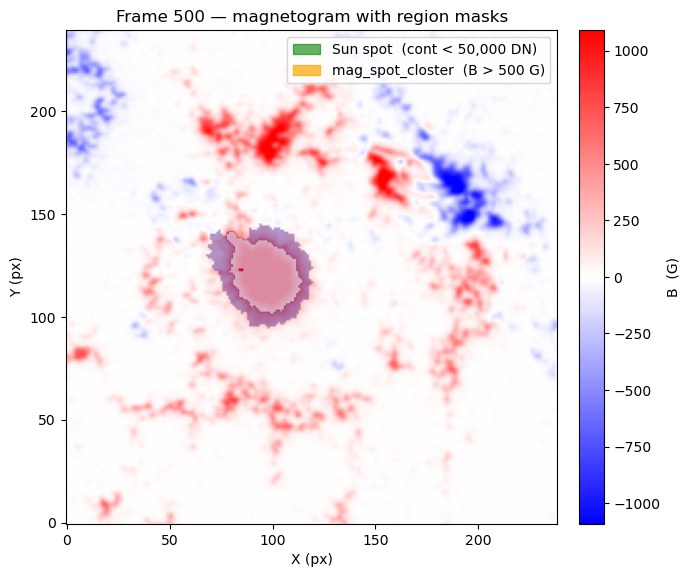

In [57]:
mag_spot_closter = (cube_mag > 500) & sun_spot

fig, ax = plt.subplots(figsize=(7, 7))

image_idx = 500

vmax = np.nanpercentile(np.abs(cube_mag[image_idx][np.isfinite(cube_mag[image_idx])]), 99)
im = ax.imshow(cube_mag[image_idx], cmap='bwr', origin='lower', vmin=-vmax, vmax=vmax)
fig.colorbar(im, ax=ax, label='B  (G)', fraction=0.046, pad=0.04)

ax.imshow(np.where(sun_spot[image_idx],         1.0, np.nan), cmap='Purples',  alpha=0.4, origin='lower', vmin=0, vmax=1)
ax.imshow(np.where(mag_spot_closter[image_idx], 1.0, np.nan), cmap='gray', alpha=0.55, origin='lower', vmin=0, vmax=1)

ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
ax.set_title(f'Frame {image_idx} — magnetogram with region masks')
ax.legend(handles=[
    mpatches.Patch(color='green',  alpha=0.6, label=f'Sun spot  (cont < {CONT_THRESH_PEM:,} DN)'),
    mpatches.Patch(color='orange', alpha=0.7, label='mag_spot_closter  (B > 500 G)'),
], loc='upper right')
plt.tight_layout()
plt.show()

### compute metrics

In [58]:
from scipy.ndimage import center_of_mass
cms = np.array([center_of_mass(umbra[i]) for i in range(penumbra.shape[0])])

In [59]:
# mean over penumbra region per frame


mean_mag_umb = np.array([np.nanmean(cube_mag[t][umbra[t]]) if umbra[t].any() else np.nan for t in range(n_t)])
mean_mag_pen = np.array([np.nanmean(cube_mag[t][penumbra[t]]) if penumbra[t].any() else np.nan for t in range(n_t)])
mean_mag_both = np.array([np.nanmean(cube_mag[t][mag_spot_closter[t]]) if both[t].any() else np.nan for t in range(n_t)])
mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t]) for t in range(cube_mag_qsun.shape[0])])

mean_dop_pen = np.array([np.nanmean(cube_dop[t][penumbra[t]]) if penumbra[t].any() else np.nan for t in range(n_t)])
mean_dop_umb = np.array([np.nanmean(cube_dop[t][umbra[t]]) if umbra[t].any() else np.nan for t in range(n_t)])
mean_dop_both = np.array([np.nanmean(cube_dop[t][both[t]]) if both[t].any() else np.nan for t in range(n_t)])
mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(cube_dop_qsun.shape[0])])

n_pix = umbra.sum(axis=(1, 2))
print(f'Penumbra pixels / frame  →  mean={n_pix.mean():.0f}, min={n_pix.min()}, max={n_pix.max()}')
print(f'Mean B over penumbra  : {np.nanmean(mean_mag_umb):.1f} G')
print(f'Mean B over umbra  : {np.nanmean(mean_mag_pen):.1f} G')
print(f'Mean v over penumbra  : {np.nanmean(mean_dop_pen):.1f} m/s')
print(f'Mean v over umbra  : {np.nanmean(mean_dop_umb):.1f} m/s')

Penumbra pixels / frame  →  mean=286, min=108, max=370
Mean B over penumbra  : 1200.5 G
Mean B over umbra  : 452.7 G
Mean v over penumbra  : -299.1 m/s
Mean v over umbra  : -212.5 m/s


In [47]:
area_pen = penumbra.sum(axis=(1, 2))
area_umb = umbra.sum(axis=(1, 2))
area_both = both.sum(axis=(1, 2))



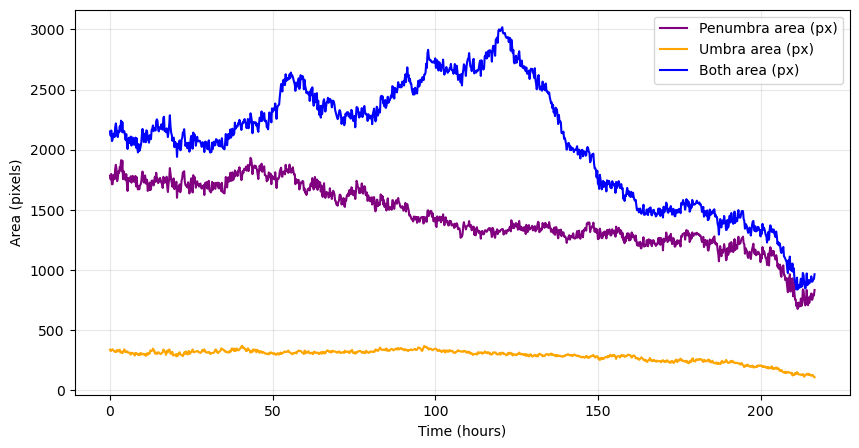

In [60]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(time_h, area_pen, label='Penumbra area (px)', color='purple')
ax1.plot(time_h, area_umb, label='Umbra area (px)', color='orange')
ax1.plot(time_h, area_both, label='Both area (px)', color='blue')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Area (pixels)')
ax1.grid(alpha=0.3)
ax1.legend()
plt.show()

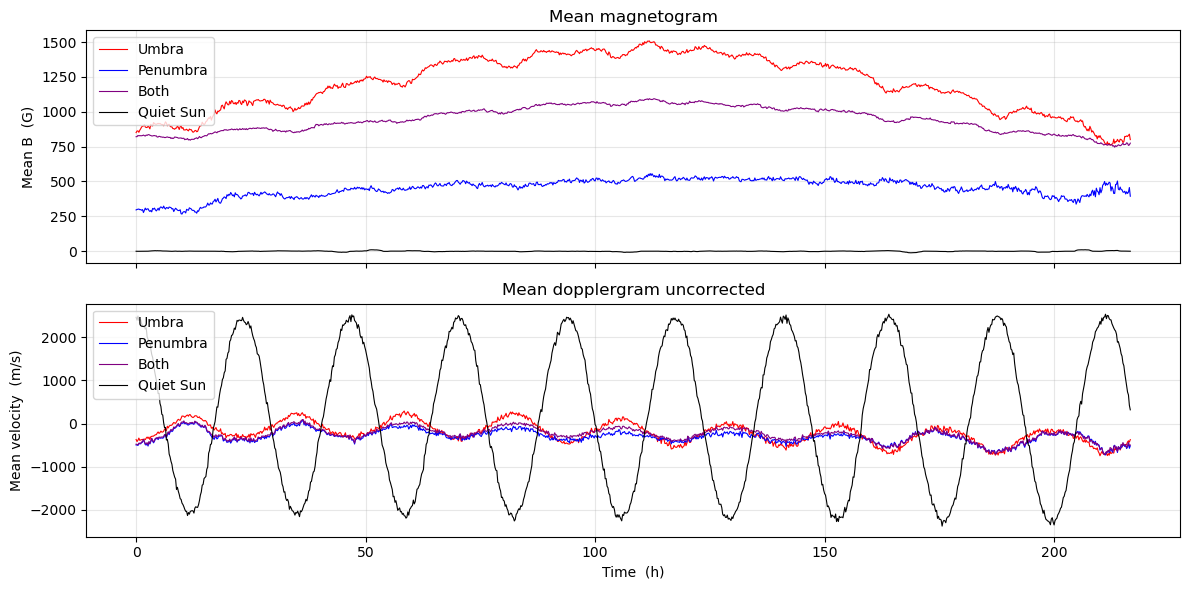

In [61]:
# ── time-series: mean magnetogram & dopplergram over the penumbra ────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(time_h, mean_mag_umb, color='red', lw=0.8, label='Umbra')
ax1.plot(time_h, mean_mag_pen, color='blue', lw=0.8, label='Penumbra')
ax1.plot(time_h, mean_mag_both, color='purple', lw=0.8, label='Both')
ax1.plot(time_h, mean_mag_quiet, color='black', lw=0.8, label='Quiet Sun')
ax1.set_ylabel('Mean B  (G)')
ax1.set_title('Mean magnetogram')
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(time_h, mean_dop_umb, color='red', lw=0.8, label='Umbra')
ax2.plot(time_h, mean_dop_pen, color='blue', lw=0.8,label='Penumbra')
ax2.plot(time_h, mean_dop_both, color='purple', lw=0.8, label='Both')
ax2.plot(time_h, mean_dop_quiet, color='black', lw=0.8, label='Quiet Sun')
ax2.set_ylabel('Mean velocity  (m/s)')
ax2.set_xlabel('Time  (h)')
ax2.set_title('Mean dopplergram uncorrected')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


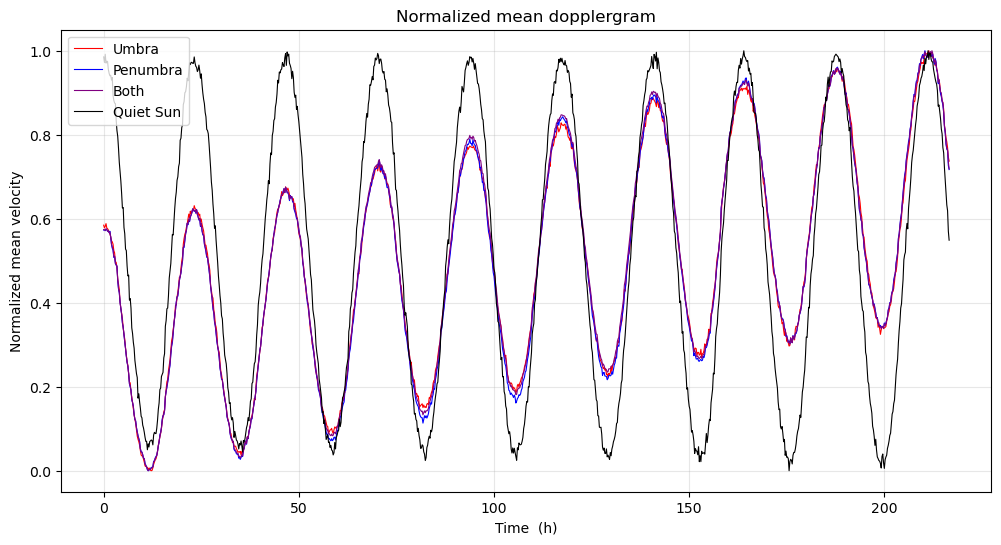

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

def normalize(arr):
    return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr))

ax.plot(time_h, normalize(mean_dop_umb), color='red', lw=0.8, label='Umbra')
ax.plot(time_h, normalize(mean_dop_pen), color='blue', lw=0.8, label='Penumbra')
ax.plot(time_h, normalize(mean_dop_both), color='purple', lw=0.8, label='Both')
ax.plot(time_h, normalize(mean_dop_quiet), color='black', lw=0.8, label='Quiet Sun')
ax.set_ylabel('Normalized mean velocity')
ax.set_xlabel('Time  (h)')
ax.set_title('Normalized mean dopplergram')
ax.grid(alpha=0.3)
ax.legend()

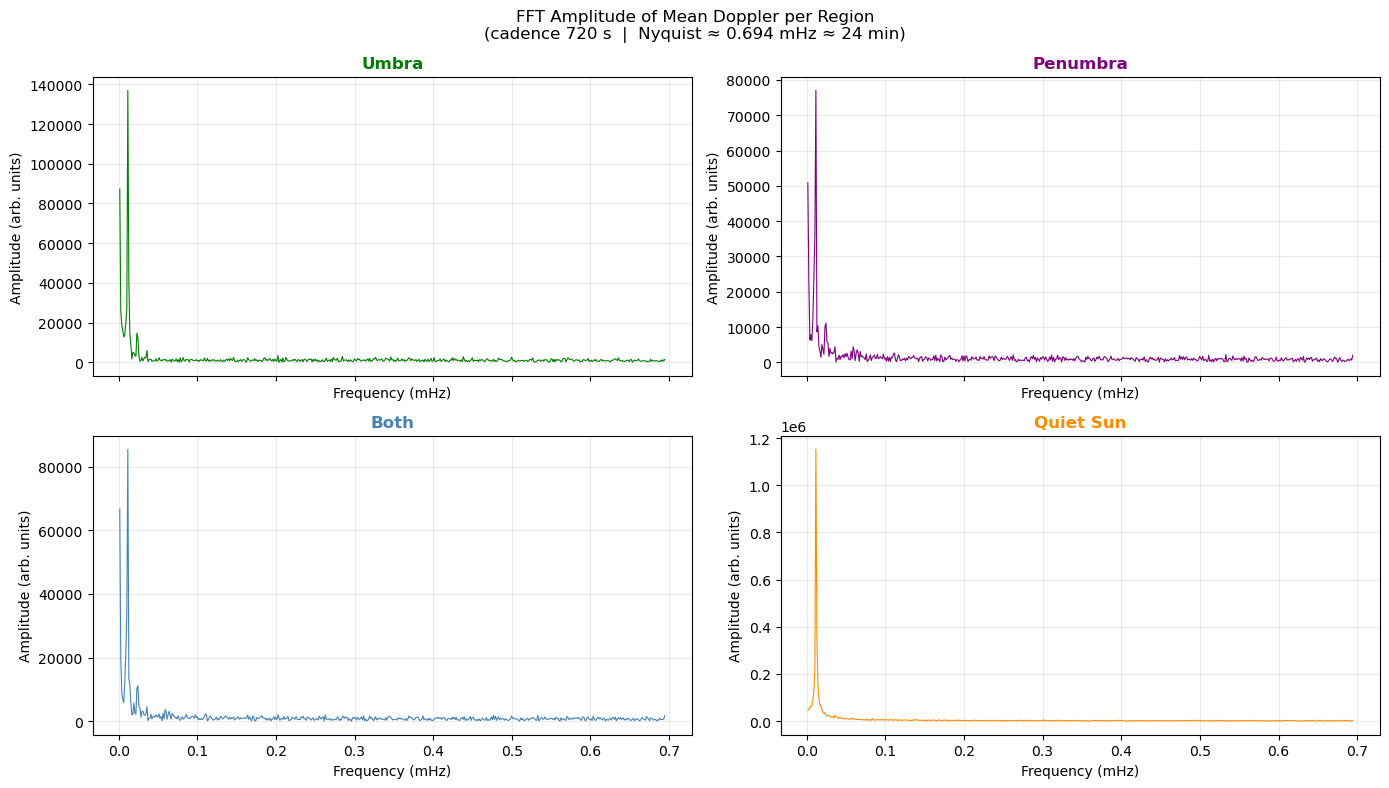

Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1445.3          1.0000
Umbra            2       0.0231          722.7          0.1071
Umbra            3       0.0359          464.6          0.0435
Umbra            4       0.2024           82.3          0.0246
Umbra            5       0.2844           58.6          0.0212

Penumbra         1       0.0115         1445.3          1.0000
Penumbra         2       0.0243          684.6          0.1445
Penumbra         3       0.0051         3252.0          0.1021
Penumbra         4       0.0359          464.6          0.0578
Penumbra         5       0.0589          282.8          0.0574

Both             1       0.0115         1445.3          1.0000
Both             2       0.0243          684.6          0.1306
Both             3       0.0359          464.6          0.0531
Both             4       0.0589          282.8         

In [33]:
from scipy.signal import find_peaks

dt        = CADENCE_S                          # 720 s
freqs_hz  = np.fft.rfftfreq(n_t, d=dt)        # Hz  (length n_t//2 + 1)
f_hz      = freqs_hz[1:]                       # skip DC
f_mhz     = f_hz * 1e3                         # mHz

def compute_fft(ts):
    ts_c = np.array(ts, dtype=float)
    nans = ~np.isfinite(ts_c)
    if nans.any() and (~nans).sum() > 2:
        x = np.arange(len(ts_c))
        ts_c[nans] = np.interp(x[nans], x[~nans], ts_c[~nans])
    return np.abs(np.fft.rfft(ts_c))

ffts = {
    'Umbra'    : (compute_fft(mean_dop_umb)[1:],   'green'),
    'Penumbra' : (compute_fft(mean_dop_pen)[1:],   'purple'),
    'Both'     : (compute_fft(mean_dop_both)[1:],  'steelblue'),
    'Quiet Sun': (compute_fft(mean_dop_quiet)[1:], 'darkorange'),
}

# ── FFT amplitude plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, (name, (amp, color)) in zip(axes.flat, ffts.items()):
    ax.plot(f_mhz, amp, color=color, lw=0.8)

    peaks, _ = find_peaks(amp, height=np.percentile(amp, 85), distance=5)
    top5 = peaks[np.argsort(amp[peaks])[::-1][:5]]
    for idx in sorted(top5):
        period_min = 1000 / (f_mhz[idx] * 60)   # minutes
        #ax.axvline(f_mhz[idx], color=color, lw=0.7, ls='--', alpha=0.5)
        #ax.text(f_mhz[idx], amp[idx] * 1.05,
        #        f'{period_min:.0f} min', fontsize=7, color=color,
        #        rotation=90, va='bottom', ha='center')

    ax.set_title(name, color=color, fontweight='bold')
    ax.set_ylabel('Amplitude (arb. units)')
    ax.set_xlabel('Frequency (mHz)')
    ax.grid(alpha=0.25, which='major')

fig.suptitle('FFT Amplitude of Mean Doppler per Region\n(cadence 720 s  |  Nyquist ≈ {:.3f} mHz ≈ {:.0f} min)'.format(
    f_mhz[-1], 1000 / (f_mhz[-1] * 60)), fontsize=12)
plt.tight_layout()
plt.show()

# ── principal peak table ──────────────────────────────────────────────────────
print(f'{"Region":<12}  {"Rank":>4}  {"Freq (mHz)":>11}  {"Period (min)":>13}  {"Rel. amplitude":>14}')
print('─' * 60)
for name, (amp, _) in ffts.items():
    peaks, _ = find_peaks(amp, height=np.percentile(amp, 85), distance=5)
    top5 = peaks[np.argsort(amp[peaks])[::-1][:5]]
    a_max = amp.max()
    for rank, idx in enumerate(top5, 1):
        print(f'{name:<12}  {rank:>4}  {f_mhz[idx]:>11.4f}  '
              f'{1000/(f_mhz[idx]*60):>13.1f}  {amp[idx]/a_max:>14.4f}')
    print()


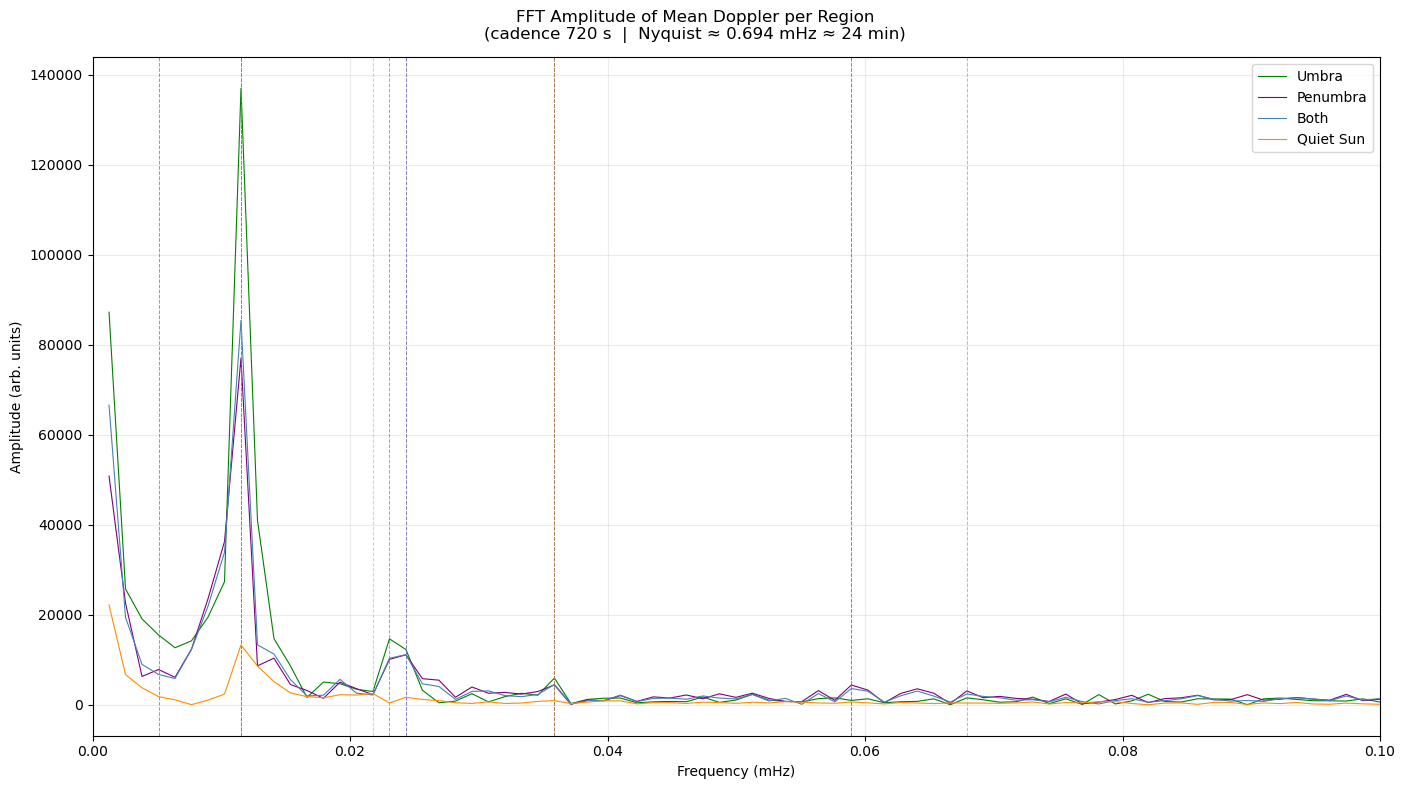

Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1445.3          1.0000
Umbra            2       0.0231          722.7          0.1071
Umbra            3       0.0359          464.6          0.0435
Umbra            4       0.2024           82.3          0.0246
Umbra            5       0.2844           58.6          0.0212

Penumbra         1       0.0115         1445.3          1.0000
Penumbra         2       0.0243          684.6          0.1445
Penumbra         3       0.0051         3252.0          0.1021
Penumbra         4       0.0359          464.6          0.0578
Penumbra         5       0.0589          282.8          0.0574

Both             1       0.0115         1445.3          1.0000
Both             2       0.0243          684.6          0.1306
Both             3       0.0359          464.6          0.0531
Both             4       0.0589          282.8         

In [24]:
from scipy.signal import find_peaks

dt        = CADENCE_S                          # 720 s
freqs_hz  = np.fft.rfftfreq(n_t, d=dt)        # Hz  (length n_t//2 + 1)
f_hz      = freqs_hz[1:]                       # skip DC
f_mhz     = f_hz * 1e3                         # mHz

def compute_fft(ts):
    ts_c = np.array(ts, dtype=float)
    nans = ~np.isfinite(ts_c)
    if nans.any() and (~nans).sum() > 2:
        x = np.arange(len(ts_c))
        ts_c[nans] = np.interp(x[nans], x[~nans], ts_c[~nans])
    return np.abs(np.fft.rfft(ts_c))

ffts = {
    'Umbra'    : (compute_fft(mean_dop_umb)[1:],   'green'),
    'Penumbra' : (compute_fft(mean_dop_pen)[1:],   'purple'),
    'Both'     : (compute_fft(mean_dop_both)[1:],  'steelblue'),
    'Quiet Sun': (compute_fft(mean_dop_quiet)[1:], 'darkorange'),
}

# ── FFT amplitude plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(14, 8), sharex=True)

for (name, (amp, color)) in ffts.items():
    ax.plot(f_mhz, amp, color=color, lw=0.8,label=name)

    peaks, _ = find_peaks(amp, height=np.percentile(amp, 85), distance=5)
    top5 = peaks[np.argsort(amp[peaks])[::-1][:5]]
    for idx in sorted(top5):
        period_min = 1000 / (f_mhz[idx] * 60)   # minutes
        ax.axvline(f_mhz[idx], color=color, lw=0.7, ls='--', alpha=0.5)
        #ax.text(f_mhz[idx], amp[idx] * 1.05,
        #        f'{period_min:.0f} min', fontsize=7, color=color,
        #        rotation=90, va='bottom', ha='center')

#ax.set_title('FFT Amplitude', color=color, fontweight='bold')
ax.set_ylabel('Amplitude (arb. units)')
ax.set_xlabel('Frequency (mHz)')
ax.grid(alpha=0.25, which='major')
ax.legend()

fig.suptitle('FFT Amplitude of Mean Doppler per Region\n(cadence 720 s  |  Nyquist ≈ {:.3f} mHz ≈ {:.0f} min)'.format(
    f_mhz[-1], 1000 / (f_mhz[-1] * 60)), fontsize=12)
plt.tight_layout()
plt.xlim(0,0.1)
plt.show()

# ── principal peak table ──────────────────────────────────────────────────────
print(f'{"Region":<12}  {"Rank":>4}  {"Freq (mHz)":>11}  {"Period (min)":>13}  {"Rel. amplitude":>14}')
print('─' * 60)
for name, (amp, _) in ffts.items():
    peaks, _ = find_peaks(amp, height=np.percentile(amp, 85), distance=5)
    top5 = peaks[np.argsort(amp[peaks])[::-1][:5]]
    a_max = amp.max()
    for rank, idx in enumerate(top5, 1):
        print(f'{name:<12}  {rank:>4}  {f_mhz[idx]:>11.4f}  '
              f'{1000/(f_mhz[idx]*60):>13.1f}  {amp[idx]/a_max:>14.4f}')
    print()




```
Region        Rank   Freq (mHz)   Period (min)  Rel. amplitude
────────────────────────────────────────────────────────────
Umbra            1       0.0115         1445.3          1.0000 Q
Umbra            2       0.0051         3252.0          0.1330 U
Umbra            3       0.0231          722.7          0.1103 Q
Umbra            4       0.0359          464.6          0.0426 U
Umbra            5       0.2024           82.3          0.0237 Q

Penumbra         1       0.0115         1445.3          1.0000 Q
Penumbra         2       0.0243          684.6          0.1422 Q
Penumbra         3       0.0359          464.6          0.0553 U
Penumbra         4       0.0589          282.8          0.0536 Q
Penumbra         5       0.1102          151.3          0.0331 Q

Both             1       0.0115         1445.3          1.0000
Both             2       0.0243          684.6          0.1306
Both             3       0.0359          464.6          0.0531
Both             4       0.0589          282.8          0.0425
Both             5       0.0679          245.4          0.0284

Quiet Sun        1       0.0115         1445.3          0.5992
Quiet Sun        2       0.0218          765.2          0.1129
Quiet Sun        3       0.0359          464.6          0.0431
Quiet Sun        4       0.6880           24.2          0.0402
Quiet Sun        5       0.2037           81.8          0.0358
```

In [25]:
save_path = pathlib.Path('../data/processed/sebastian_sun_spots/DS03/anim.html')

In [26]:
import matplotlib
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as mpatches

matplotlib.rcParams['animation.embed_limit'] = 50   # MB

STEP = 50
frames_idx = np.arange(0, n_t, STEP)

cubes_ch  = [cube_cont,       cube_mag,         cube_dop]
cmaps_ch  = ['gray',          'bwr',             'RdBu_r']
labels_ch = ['Continuum (DN)','Magnetogram (G)', 'Dopplergram (m/s)']
clims     = [np.nanpercentile(c, [2, 98]) for c in cubes_ch]

def _make_rgba(umb, pen):
    """Green for umbra, purple for penumbra, transparent elsewhere."""
    h, w = umb.shape
    rgba = np.zeros((h, w, 4), dtype=float)
    rgba[pen, 0] = 0.55;  rgba[pen, 2] = 1.0;   rgba[pen, 3] = 0.40  # purple
    rgba[umb, 0] = 0.0;   rgba[umb, 1] = 0.85;  rgba[umb, 3] = 0.45  # green
    return rgba

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ims = []; overlays = []

for ax, cube, cmap, clim, lbl in zip(axes, cubes_ch, cmaps_ch, clims, labels_ch):
    im = ax.imshow(cube[0], origin='lower', cmap=cmap,
                   vmin=clim[0], vmax=clim[1], interpolation='nearest')
    fig.colorbar(im, ax=ax, label=lbl, fraction=0.046, pad=0.04)
    ov = ax.imshow(_make_rgba(umbra[0], penumbra[0]), origin='lower', interpolation='nearest')
    ax.set_xlabel('X (px)'); ax.set_ylabel('Y (px)')
    ax.text(0.02, 0.02, 'Cadence: 720 s', transform=ax.transAxes,
            color='white', fontsize=9, va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))
    ims.append(im); overlays.append(ov)

# legend (only needs to appear once — add to left panel)
axes[0].legend(handles=[
    mpatches.Patch(color=(0.0, 0.85, 0.0, 0.7), label='Umbra'),
    mpatches.Patch(color=(0.55, 0.0, 1.0, 0.7), label='Penumbra'),
], loc='upper right', fontsize=8)

suptitle = fig.suptitle('', y=1.01)

def _update_regions(i):
    t = frames_idx[i]
    rgba = _make_rgba(umbra[t], penumbra[t])
    for im, ov, cube in zip(ims, overlays, cubes_ch):
        im.set_data(cube[t])
        ov.set_data(rgba)
    elapsed_h = t * CADENCE_S / 3600
    b_u = f'{mean_mag_umb[t]:.0f}' if np.isfinite(mean_mag_umb[t]) else 'N/A'
    b_p = f'{mean_mag_pen[t]:.0f}' if np.isfinite(mean_mag_pen[t]) else 'N/A'
    suptitle.set_text(
        f'SDO/HMI  |  frame {t:04d}  |  t = {elapsed_h:.2f} h  |  '
        f'<B> umb={b_u} G   pen={b_p} G'
    )
    return ims + overlays

anim = FuncAnimation(fig, _update_regions, frames=len(frames_idx), interval=100, blit=False)
plt.close(fig)
#safe the animation as HTML
anim.save(save_path, writer='html', fps=5)
#uncoment to see the animation in the notebook (may be too large to embed)
#HTML(anim.to_jshtml())


2026-06-03 22:12:51 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.HTMLWriter'>


<file:///home/thomas/Desktop/sun_spots_pulsation_review/data/processed/sebastian_sun_spots/DS03/anim.html>